The travel dataset provides detailed information on various trips taken by travelers, including their destination, travel dates, duration of the trip in days, traveler demographics (name, age, gender, and nationality), as well as the type and cost of accommodation and transportation.

In [1]:
import pandas as pd
import numpy as np

In [2]:
# load dataset
data = pd.read_csv('Travel details dataset.csv')

In [3]:
data

,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
0,1,"London, UK",5/1/2023,5/8/2023,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600
1,2,"Phuket, Thailand",6/15/2023,6/20/2023,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500
2,3,"Bali, Indonesia",7/1/2023,7/8/2023,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700
3,4,"New York, USA",8/15/2023,8/29/2023,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000
4,5,"Tokyo, Japan",9/10/2023,9/17/2023,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,135,"Rio de Janeiro, Brazil",8/1/2023,8/10/2023,9.0,Jose Perez,37.0,Male,Brazilian,Hostel,2500,Car,2000
135,136,"Vancouver, Canada",8/15/2023,8/21/2023,6.0,Emma Wilson,29.0,Female,Canadian,Hotel,5000,Airplane,3000
136,137,"Bangkok, Thailand",9/1/2023,9/8/2023,7.0,Ryan Chen,34.0,Male,Chinese,Hostel,2000,Train,1000
137,138,"Barcelona, Spain",9/15/2023,9/22/2023,7.0,Sofia Rodriguez,25.0,Female,Spanish,Airbnb,6000,Airplane,2500


In [4]:
data.sample(5)

,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
130,131,"Cape Town, South Africa",6/1/2023,6/10/2023,9.0,Michael Johnson,45.0,Male,South African,Hostel,3000,Car,2000
22,23,Rome,11/1/2023,11/8/2023,7.0,Sofia Russo,29.0,Female,Italian,Airbnb,$700,Train,$80
124,125,"Sydney, Aus",11/11/2022,11/21/2022,10.0,Isabella Chen,30.0,Female,Chinese,Airbnb,900,Plane,1000
89,90,Dubai,1/1/2022,1/8/2022,8.0,Fatima Ahmed,24.0,Female,Emirati,Hotel,1000 USD,Plane,800 USD
56,57,"Barcelona, Spain",4/5/2024,4/13/2024,8.0,Laura Gomez,29.0,Female,Spanish,Airbnb,$700,Car rental,$250


In [5]:
data.head(5)

,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
0,1,"London, UK",5/1/2023,5/8/2023,7.0,John Smith,35.0,Male,American,Hotel,1200,Flight,600
1,2,"Phuket, Thailand",6/15/2023,6/20/2023,5.0,Jane Doe,28.0,Female,Canadian,Resort,800,Flight,500
2,3,"Bali, Indonesia",7/1/2023,7/8/2023,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700
3,4,"New York, USA",8/15/2023,8/29/2023,14.0,Sarah Johnson,29.0,Female,British,Hotel,2000,Flight,1000
4,5,"Tokyo, Japan",9/10/2023,9/17/2023,7.0,Kim Nguyen,26.0,Female,Vietnamese,Airbnb,700,Train,200


In [6]:
data.tail(5)

,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
134,135,"Rio de Janeiro, Brazil",8/1/2023,8/10/2023,9.0,Jose Perez,37.0,Male,Brazilian,Hostel,2500,Car,2000
135,136,"Vancouver, Canada",8/15/2023,8/21/2023,6.0,Emma Wilson,29.0,Female,Canadian,Hotel,5000,Airplane,3000
136,137,"Bangkok, Thailand",9/1/2023,9/8/2023,7.0,Ryan Chen,34.0,Male,Chinese,Hostel,2000,Train,1000
137,138,"Barcelona, Spain",9/15/2023,9/22/2023,7.0,Sofia Rodriguez,25.0,Female,Spanish,Airbnb,6000,Airplane,2500
138,139,"Auckland, New Zealand",10/1/2023,10/8/2023,7.0,William Brown,39.0,Male,New Zealander,Hotel,7000,Train,2500


Section 1 Data understanding (Q1 – Q8)

    Q1. What is the shape of the dataset — total rows and columns?

In [7]:
data.shape

(139, 13)

rows = 139 

columns = 13


    Q2. What are the column names and their data types? How many numerical vs categorical columns are there?

In [8]:
print(data.columns)
print()
data.info()

Index(['Trip ID', 'Destination', 'Start date', 'End date', 'Duration (days)',
       'Traveler name', 'Traveler age', 'Traveler gender',
       'Traveler nationality', 'Accommodation type', 'Accommodation cost',
       'Transportation type', 'Transportation cost'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Trip ID               139 non-null    int64  
 1   Destination           137 non-null    object 
 2   Start date            137 non-null    object 
 3   End date              137 non-null    object 
 4   Duration (days)       137 non-null    float64
 5   Traveler name         137 non-null    object 
 6   Traveler age          137 non-null    float64
 7   Traveler gender       137 non-null    object 
 8   Traveler nationality  137 non-null    object 
 9   Accommodation type    137 non-null    ob

numerical column = 3, 
categorical column = 10

In [9]:
data['Accommodation cost'].dropna(inplace=True)
data['Transportation cost'].dropna(inplace=True)

since the cost must be numerical so converting Transportation cost and  Accommodation cost  to numerical columns

In [10]:
# 1. Remove the '$' sign from the Accommodation cost column
data['Accommodation cost'] = data['Accommodation cost'].str.replace('$', '', regex=False)
data['Accommodation cost'] = data['Accommodation cost'].str.replace('USD', '', regex=False)
data['Accommodation cost'] = data['Accommodation cost'].str.replace(',', '', regex=False)
data['Accommodation cost'] = data['Accommodation cost'].str.replace('NaN', '', regex=False)
# Convert to integer
data['Accommodation cost'] = data['Accommodation cost'].astype('Int64')

# 1. Remove the '$' sign from the Accommodation cost column
data['Transportation cost'] = data['Transportation cost'].str.replace('$', '', regex=False)
data['Transportation cost'] = data['Transportation cost'].str.replace('USD', '', regex=False)
data['Transportation cost'] = data['Transportation cost'].str.replace(',', '', regex=False)
data['Transportation cost'] = data['Transportation cost'].str.replace('NaN', '', regex=False)
# Convert to integer
data['Transportation cost'] = data['Transportation cost'].astype('Int64')


In [11]:
data.sample(20)

,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost
113,114,Santorini,7/15/2022,7/22/2022,7.0,George Chen,27.0,Male,Greece,Airbnb,1000,Ferry,150
21,22,Sydney,12/5/2023,12/12/2023,7.0,James Wilson,32.0,Male,Australian,Hotel,1000,Plane,600
16,17,Paris,9/1/2023,9/10/2023,9.0,Sarah Johnson,30.0,Female,American,Hotel,900,Plane,400
106,107,Tokyo,9/1/2022,9/10/2022,9.0,Sarah Lee,28.0,Female,South Korea,Airbnb,800,Train,500
79,80,"Bangkok, Thai",5/15/2024,5/22/2024,7.0,Nana Kwon,27.0,Female,Korean,Hotel,400,Plane,400
103,104,Bali,7/22/2024,7/28/2024,6.0,Olivia Kim,29.0,Female,South Korea,Villa,1200,Plane,1000
2,3,"Bali, Indonesia",7/1/2023,7/8/2023,7.0,David Lee,45.0,Male,Korean,Villa,1000,Flight,700
5,6,"Paris, France",10/5/2023,10/10/2023,5.0,Michael Brown,42.0,Male,American,Hotel,1500,Flight,800
45,46,"New York City, USA",9/15/2022,9/22/2022,7.0,Michael Davis,41.0,Male,American,Hotel,1500,Plane,500
63,64,Sydney,6/23/2023,6/29/2023,6.0,David Lee,43.0,Male,Australian,Hotel,1500,Plane,1200


    Q3. What are the basic statistics — mean, median, min, max, and std — for all numerical columns?

In [12]:
data.describe()

,Trip ID,Duration (days),Traveler age,Accommodation cost,Transportation cost
count,139.000000,137.000000,137.000000,137.0,136.0
mean,70.000000,7.605839,33.175182,1245.109489,645.183824
std,40.269923,1.601276,7.145441,1337.349836,584.476153
min,1.000000,5.000000,20.000000,100.0,20.0
25%,35.500000,7.000000,28.000000,600.0,200.0
50%,70.000000,7.000000,31.000000,900.0,550.0
75%,104.500000,8.000000,38.000000,1200.0,800.0
max,139.000000,14.000000,60.000000,8000.0,3000.0


    4. How many missing values are in each column? Which column has the most?

In [13]:
data.isna().sum()

Trip ID                 0
Destination             2
Start date              2
End date                2
Duration (days)         2
Traveler name           2
Traveler age            2
Traveler gender         2
Traveler nationality    2
Accommodation type      2
Accommodation cost      2
Transportation type     3
Transportation cost     3
dtype: int64

In [14]:
data['Transportation cost'].isna().sum()

np.int64(3)

Transportation type and Transportation cost has the most missing values. i.e 3 and all other columns have 2 missing values.

    5. Are there any duplicate rows or duplicate Trip IDs?

In [15]:
data.duplicated().sum()

np.int64(0)

no duplicate rows.

In [16]:
data['Trip ID'].duplicated().sum()

np.int64(0)

no any duplicate Trip IDS

    6. How many unique destinations are there? List them.

In [17]:
print("Total number of unique Destination = ",data['Destination'].nunique())

data['Destination'].unique()

Total number of unique Destination =  59


array(['London, UK', 'Phuket, Thailand', 'Bali, Indonesia',
       'New York, USA', 'Tokyo, Japan', 'Paris, France',
       'Sydney, Australia', 'Rio de Janeiro, Brazil',
       'Amsterdam, Netherlands', 'Dubai, United Arab Emirates',
       'Cancun, Mexico', 'Barcelona, Spain', 'Honolulu, Hawaii',
       'Berlin, Germany', 'Marrakech, Morocco', 'Edinburgh, Scotland',
       'Paris', 'Bali', 'London', 'Tokyo', 'New York', 'Sydney', 'Rome',
       'Bangkok', 'Hawaii', 'Barcelona', 'Japan', 'Thailand', 'France',
       'Australia', 'Brazil', 'Greece', 'Egypt', 'Mexico', 'Italy',
       'Spain', 'Canada', 'New York City, USA', 'Bangkok, Thailand',
       'Vancouver, Canada', 'Sydney, AUS', 'Seoul, South Korea',
       'Los Angeles, USA', 'Rome, Italy', 'Cape Town', nan,
       'Cape Town, SA', 'Sydney, Aus', 'Bangkok, Thai', 'Phuket, Thai',
       'Dubai', 'Seoul', 'Rio de Janeiro', 'Amsterdam', 'Phuket',
       'Santorini', 'Phnom Penh', 'Athens, Greece',
       'Cape Town, South Africa'

7. What is the range of Traveler age, Duration (days), Accommodation cost, and Transportation cost?

In [18]:
#function to find the range of the columns.
def find_range(column):
    minimum = data[column].min()
    maximum = data[column].max()
    column_range = maximum - minimum  # Changed variable name from 'range' to 'column_range'
    return column_range

# Pass the column name as a string
Range_of_Traveler_age = find_range('Traveler age')
Range_of_Duration = find_range('Duration (days)')
Range_of_Accommodation_cost = find_range('Accommodation cost')
Range_of_Transportation_cost = find_range('Transportation cost')

In [19]:
print(f" Range of Traveler age = {Range_of_Traveler_age}")
print(f" Range of Duration (days) = {Range_of_Duration}")
print(f" Range of Accommodation cost = {Range_of_Accommodation_cost}")
print(f" Range of Transportation cost = {Range_of_Transportation_cost}")

 Range of Traveler age = 40.0
 Range of Duration (days) = 9.0
 Range of Accommodation cost = 7900
 Range of Transportation cost = 2980


8. Are there inconsistent category values in Transportation type — e.g., "Flight" vs "Plane", "Car" vs "Car rental"?

In [20]:
data['Transportation type'].value_counts()

Transportation type
Plane         57
Train         37
Flight        13
Car rental    13
Bus            6
Airplane       5
Car            3
Subway         1
Ferry          1
Name: count, dtype: int64

yes, there are inconsistent values like Plan, Flight, and Airplane which means the same thing.

🟠 Section 2 — Data Cleaning (Q9–Q16)

9. Standardize inconsistent Transportation type values (merge "Flight" + "Plane" → "Flight", "Car" + "Car rental" → "Car rental").

In [21]:
# Merge the categories
data['Transportation type'] = data['Transportation type'].replace({
    'Plane': 'Flight',
    'Airplane': 'Flight',
    'Car': 'Car rental'
})

In [22]:
data['Transportation type'].value_counts()

Transportation type
Flight        75
Train         37
Car rental    16
Bus            6
Subway         1
Ferry          1
Name: count, dtype: int64

10. Drop rows with missing values? — How many rows remain?

In [23]:
data.isna().sum()

Trip ID                 0
Destination             2
Start date              2
End date                2
Duration (days)         2
Traveler name           2
Traveler age            2
Traveler gender         2
Traveler nationality    2
Accommodation type      2
Accommodation cost      2
Transportation type     3
Transportation cost     3
dtype: int64

In [24]:
data.dropna(inplace=True)

In [25]:
data.isna().sum()

Trip ID                 0
Destination             0
Start date              0
End date                0
Duration (days)         0
Traveler name           0
Traveler age            0
Traveler gender         0
Traveler nationality    0
Accommodation type      0
Accommodation cost      0
Transportation type     0
Transportation cost     0
dtype: int64

In [26]:
data.shape

(136, 13)

Remaining Row = 136 ( Previous Row = 139)

11. Convert Start date and End date columns to proper datetime format.

In [27]:
data['Start date'] = pd.to_datetime(data['Start date'])
data['End date'] = pd.to_datetime(data['End date'])

12. Detect outliers in Accommodation cost and Transportation cost using the IQR method. How many outliers exist?

In [28]:
# function to check and handle outliers

def handle_outliers(df, column_name):
    # 1. Calculate IQR statistics using clean, local variable names
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    # 2. Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 3. Find and count outliers
    outliers_mask = (df[column_name] < lower_bound) | (df[column_name] > upper_bound)
    outlier_count = outliers_mask.sum()
    print(f"Found {outlier_count} outliers in '{column_name}'")
    
    return df


In [31]:
data = handle_outliers(data,'Accommodation cost')
data = handle_outliers(data,'Transportation cost')

Found 14 outliers in 'Accommodation cost'
Found 8 outliers in 'Transportation cost'


13. Engineer a new column: Total cost = Accommodation cost + Transportation cost.

In [32]:
# Create the new 'Total cost' column
data['Total cost'] = data['Accommodation cost'] + data['Transportation cost']

In [33]:
data.sample(4)

,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost,Total cost
135,136,"Vancouver, Canada",2023-08-15,2023-08-21,6.0,Emma Wilson,29.0,Female,Canadian,Hotel,5000,Flight,3000,8000
12,13,"Honolulu, Hawaii",2024-06-10,2024-06-18,8.0,Lily Wong,29.0,Female,Chinese,Resort,3000,Flight,1200,4200
58,59,"Los Angeles, USA",2024-06-20,2024-06-27,7.0,Michael Chen,26.0,Male,Chinese,Hotel,1200,Car rental,300,1500
138,139,"Auckland, New Zealand",2023-10-01,2023-10-08,7.0,William Brown,39.0,Male,New Zealander,Hotel,7000,Train,2500,9500


14. Engineer a new column: Cost per day = Total cost ÷ Duration (days).

In [36]:
data['Cost per day'] = (data['Total cost'] / data['Duration (days)']).round(2)

In [38]:
data.sample(4)

,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost,Total cost,Cost per day
47,48,"Vancouver, Canada",2022-07-10,2022-07-17,7.0,Kevin Kim,24.0,Male,Korean,Hostel,400,Train,150,550,78.57
53,54,"Rio de Janeiro, Brazil",2024-01-15,2024-01-24,9.0,Felipe Almeida,30.0,Male,Brazilian,Airbnb,800,Train,150,950,105.56
44,45,"Barcelona, Spain",2023-08-18,2023-08-25,7.0,Emma Garcia,27.0,Female,Spanish,Hostel,600,Flight,600,1200,171.43
115,116,Phnom Penh,2022-09-10,2022-09-15,5.0,Alex Ng,33.0,Male,Cambodia,Hostel,200,Flight,500,700,140.0


15. Engineer a new column: Age Group — Young (20–30), Middle (31–45), Senior (46+).

In [39]:
data.loc[(data['Traveler age']>=20) & (data['Traveler age']<=30),'Age Group'] = 'Young'
data.loc[(data['Traveler age']>=31) & (data['Traveler age']<=45),'Age Group'] = 'Middle'
data.loc[(data['Traveler age']>=46),'Age Group'] = 'Senior'

🟡 Section 3 — Data Manipulation (Q17–Q28)

16. What are the top 10 most visited destinations?

In [45]:
data['Destination'].value_counts().head(10)

Destination
Paris                     7
Bali                      7
Tokyo, Japan              7
Paris, France             7
Tokyo                     5
Sydney                    5
Rome                      5
New York                  5
Bali, Indonesia           5
Rio de Janeiro, Brazil    4
Name: count, dtype: int64

17. Which destination has the highest average total cost?

In [55]:
data.groupby('Destination')['Total cost'].mean().sort_values(ascending = False).head(1)

Destination
Auckland, New Zealand    9500.0
Name: Total cost, dtype: Float64

18. Which destination has the longest average trip duration?

In [59]:
data.groupby('Destination')['Duration (days)'].mean().sort_values(ascending = False).head(1)

Destination
Australia    13.0
Name: Duration (days), dtype: float64

19. What is the average total cost for male vs female travelers?

In [60]:
data.groupby('Traveler gender')['Total cost'].mean()

Traveler gender
Female    1935.071429
Male      1860.151515
Name: Total cost, dtype: Float64

20. Which traveler nationality travels the most?

In [63]:
data['Traveler nationality'].value_counts().head()

Traveler nationality
American      23
Korean        13
British       12
Canadian       9
Australian     8
Name: count, dtype: int64

American Travels the most then followed by Korean.

21. Which traveler nationality spends the most on average per trip?

In [67]:
data.groupby('Traveler nationality')['Total cost'].mean().sort_values(ascending=False).head()

Traveler nationality
New Zealander         9500.0
South African         2850.0
Singapore             2700.0
Emirati               2550.0
Spanish          2328.571429
Name: Total cost, dtype: Float64

Traveler nationality 'New Zealander' spends the most on average per Trip. 

22. What is the most popular accommodation type overall?

In [68]:
data['Accommodation type'].value_counts()

Accommodation type
Hotel              59
Airbnb             30
Hostel             24
Resort             14
Villa               4
Vacation rental     3
Riad                1
Guesthouse          1
Name: count, dtype: int64

Hotel is the most popular Accomodation Type.

23. Which accommodation type has the highest average cost?

In [80]:
data.groupby('Accommodation type')['Accommodation cost'].mean().sort_values(ascending=False).head()

Accommodation type
Resort             1521.428571
Hotel              1515.254237
Villa                   1425.0
Airbnb             1181.666667
Vacation rental          900.0
Name: Accommodation cost, dtype: Float64

Accomodation Type Resort has the highest average cost.

24. What is the most popular transportation type overall?

In [75]:
data['Transportation type'].value_counts()

Transportation type
Flight        75
Train         37
Car rental    16
Bus            6
Subway         1
Ferry          1
Name: count, dtype: int64

Flight is the most popular transpotation type.

25. Which transportation type costs the most on average?

In [81]:
data.groupby('Transportation type')['Transportation cost'].mean().sort_values(ascending=False).head()

Transportation type
Flight        883.333333
Car rental       509.375
Train         344.594595
Ferry              150.0
Bus            70.833333
Name: Transportation cost, dtype: Float64

Tranportation type 'Flight' cost the most on average.

26. Which month has the highest number of trips?

In [91]:
# 1. Extract the month name from the 'Start date' column.
data['Start month'] = data['Start date'].dt.strftime('%B')
data['Start month'].value_counts()

Start month
August       17
September    17
July         16
May          15
June         15
November     11
February     10
October       9
January       9
March         6
April         6
December      5
Name: count, dtype: int64

August has the highest number of trips.

27. Which age group travels the most and spends the most?

In [92]:
data['Age Group'].value_counts()

Age Group
Middle    69
Young     61
Senior     6
Name: count, dtype: int64

Middle Aged Group travels the most.

In [93]:
data.groupby('Age Group')['Total cost'].mean()

Age Group
Middle    1948.188406
Senior    1716.666667
Young     1860.655738
Name: Total cost, dtype: Float64

Middle Aged group also spend the most.

🔴 Section 4 — Data Visualization (Q29–Q42)

28. Plot a bar chart of the top 10 most visited destinations.

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

/var/folders/d8/83r4k_r15tv7zl64z94ffs640000gn/T/ipykernel_83674/387423584.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


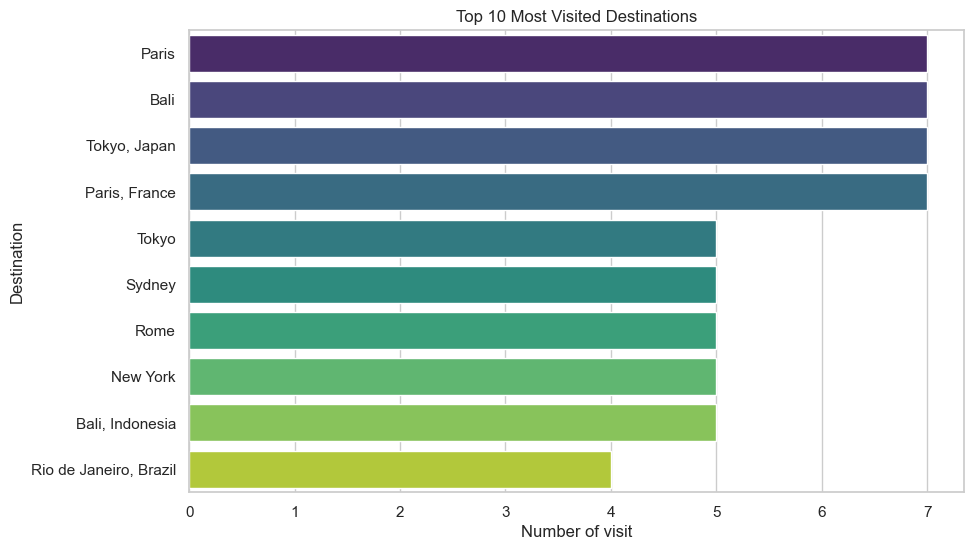

In [103]:
top_10_destinations = data['Destination'].value_counts().head(10)

# Set the style and size of the plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    x=top_10_destinations.values, 
    y=top_10_destinations.index, 
    palette="viridis"
)
plt.title('Top 10 Most Visited Destinations')
plt.xlabel('Number of visit')
plt.ylabel('Destination')
plt.show()

29. Plot a histogram of Traveler age distribution — is it normally distributed?

<Axes: xlabel='Traveler age', ylabel='Count'>

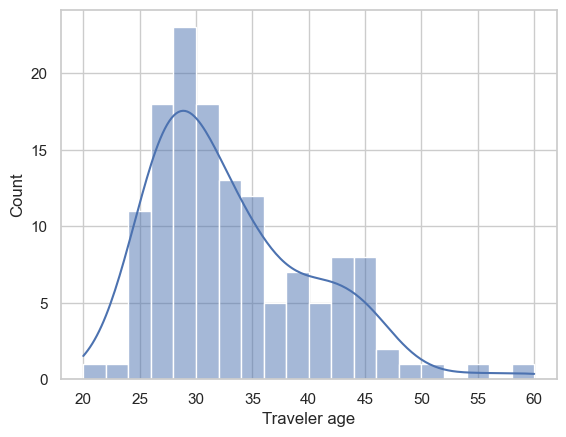

In [104]:
sns.histplot(
data=data,
x='Traveler age', # numeric variable
bins=20, # number of bins (or 'auto')
kde=True, # overlay KDE curve
)

Figure is not perfectly symmetrical but can be considered as normal distribution.

30. Plot a pie chart of Transportation type distribution.

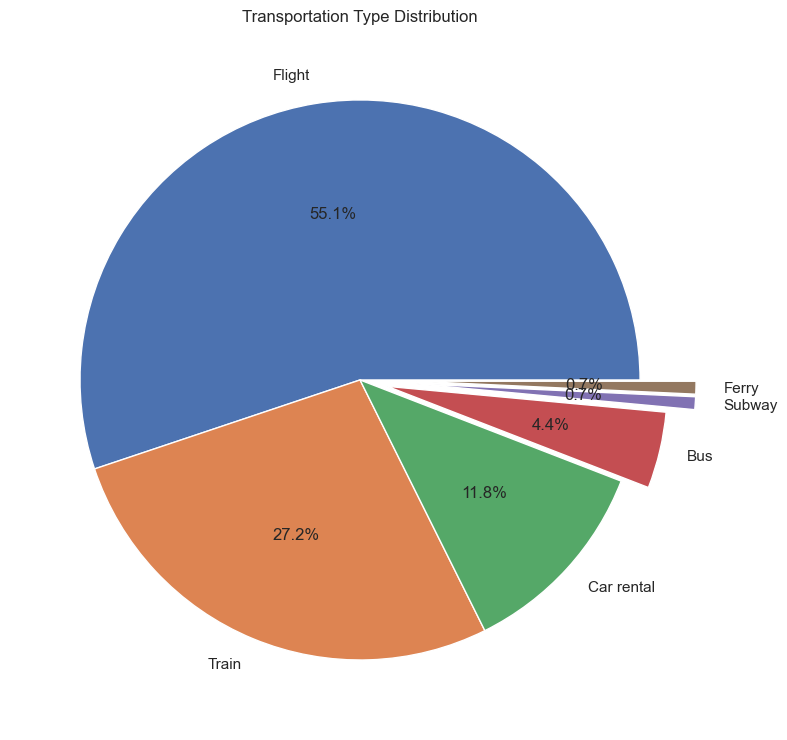

In [123]:
# Get the data distribution
transport_counts = data['Transportation type'].value_counts()

# 2. Set the figure size
plt.figure(figsize=(8, 8))
explode = (0, 0, 0, 0.1, 0.2, 0.2)
# 3. Create the pie chart
plt.pie(
    transport_counts.values, 
    labels=transport_counts.index, 
    autopct='%1.1f%%',       # This displays the percentage on each slice
    startangle=0,          # Rotates the start for a cleaner look
    explode=explode
)
plt.title('Transportation Type Distribution')
plt.tight_layout()
plt.show()

31. Plot a pie chart of Accommodation type distribution.

In [126]:
data.sample()

,Trip ID,Destination,Start date,End date,Duration (days),Traveler name,Traveler age,Traveler gender,Traveler nationality,Accommodation type,Accommodation cost,Transportation type,Transportation cost,Total cost,Cost per day,Age Group,Start month,End month
49,50,"Paris, France",2023-08-15,2023-08-22,7.0,Jennifer Nguyen,31.0,Female,Canadian,Hotel,1200,Train,300,1500,214.29,Middle,August,August


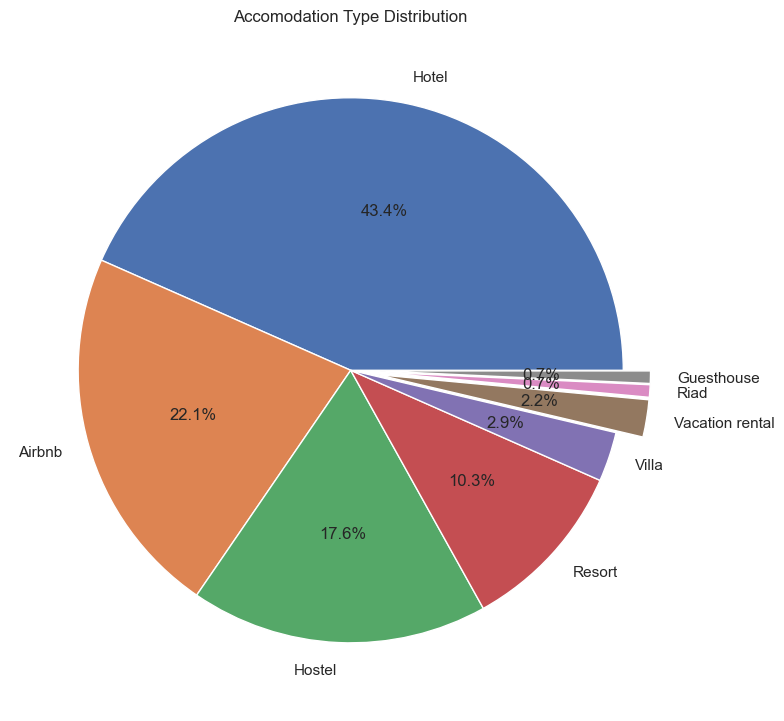

In [137]:
# Get the data distribution
accommodation_counts = data['Accommodation type'].value_counts()

# 2. Set the figure size
plt.figure(figsize=(8, 8))
explode = (0, 0, 0, 0,0, 0.1,0.1,0.1)
# 3. Create the pie chart
plt.pie(
    accommodation_counts.values, 
    labels=accommodation_counts.index, 
    autopct='%1.1f%%',       # This displays the percentage on each slice
    startangle=0,          # Rotates the start for a cleaner look
    explode=explode
)
plt.title('Accomodation Type Distribution')
plt.tight_layout()
plt.show()

32. Plot a boxplot of Total cost by Accommodation type — which type has the widest spread?

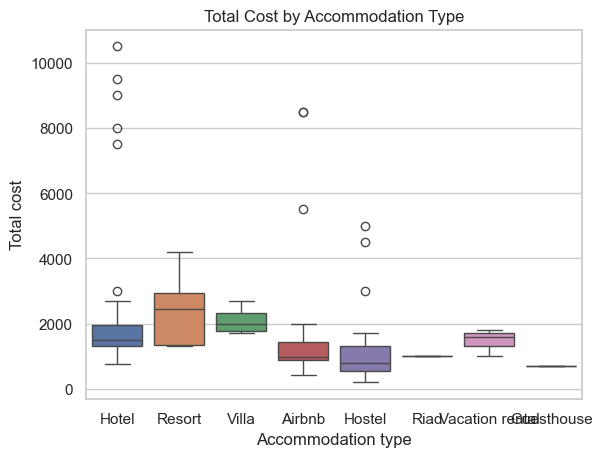

In [143]:
sns.boxplot(
    data=data,
    x='Accommodation type',
    y='Total cost',
    hue='Accommodation type'
)
plt.title('Total Cost by Accommodation Type')
plt.show()

Based on your box plot, the accommodation type with the widest spread (highest variability in cost, excluding the individual outlier dots) is Resort.

33. Plot a boxplot of Total cost by Transportation type.

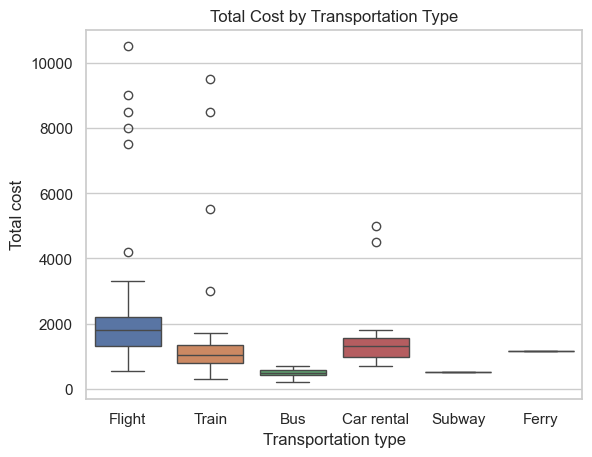

In [142]:
sns.boxplot(
    data=data,
    x='Transportation type',
    y='Total cost',
    hue='Transportation type'
)
plt.title('Total Cost by Transportation Type')
plt.show()

34. Plot a grouped bar chart of Accommodation type preference by Traveler gender.

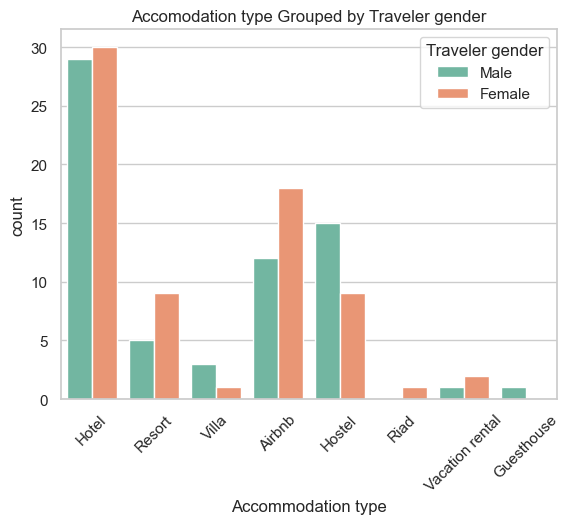

In [147]:
sns.countplot(
    data=data, 
    x='Accommodation type', 
    hue='Traveler gender', 
    palette='Set2'
)
plt.title('Accomodation type Grouped by Traveler gender')
plt.xticks(rotation=45)
plt.show()

35. Plot a scatter plot of Duration (days) vs Total cost?

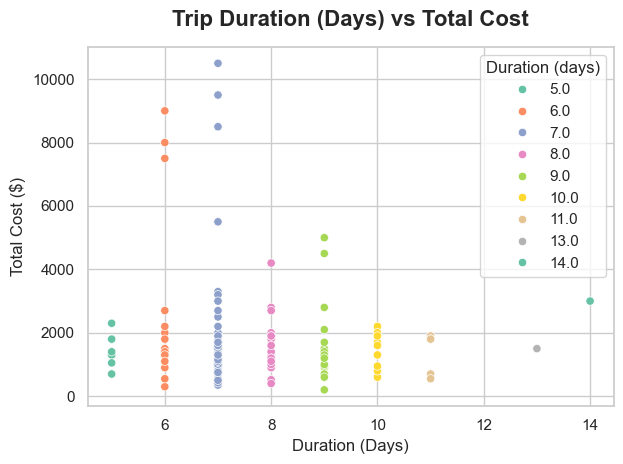

In [161]:
sns.scatterplot(
data=data,
x='Duration (days)',
y='Total cost',
hue='Duration (days)', # color by category
palette='Set2',
alpha=1 
)
plt.title('Trip Duration (Days) vs Total Cost', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Duration (Days)', fontsize=12)
plt.ylabel('Total Cost ($)', fontsize=12)

plt.tight_layout()
plt.show()